# Appartment-Hunter

### Imports de bibliothèques

In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("data/raw/kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

We find that the *date* column is an object type.
So in order to use it we'll need to turn it into a datetime type

In [12]:
df["date"]=pd.to_datetime(df["date"], errors='coerce')
df["date"].head()

0   2014-10-13
1   2014-12-09
2   2015-02-25
3   2014-12-09
4   2015-02-18
Name: date, dtype: datetime64[ns]

Actually, the date is between 2014 and 2015 so the impact of this column is very low. So we'll drop it

In [13]:
df=df.drop("date", axis=1)

In [14]:
df.duplicated().sum()
df[df.duplicated()]

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
3951,1825069031,550000.0,4,1.75,2410,8447,2.0,0,3,4,8,2060,350,1936,1980,98074,47.6499,-122.088,2520,14789
14983,6308000010,585000.0,3,2.50,2290,5089,2.0,0,0,3,9,2290,0,2001,0,98006,47.5443,-122.172,2290,7984
20054,8648900110,555000.0,3,2.50,1940,3211,2.0,0,0,3,8,1940,0,2009,0,98027,47.5644,-122.093,1880,3078


In [15]:
df = df.drop_duplicates()

0 duplicates and 0 non-null values

In [16]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161000e+04,2.161000e+04,21610.000000,21610.000000,21610.000000,2.161000e+04,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000,21610.000000
mean,4.580161e+09,5.400849e+05,3.370847,2.114739,2079.881212,1.510829e+04,1.494239,0.007543,0.234197,3.409440,7.656779,1788.347894,291.533318,1971.003609,84.322351,98077.945673,47.560049,-122.213910,1986.518695,12769.031976
std,2.876547e+09,3.671525e+05,0.930110,0.770204,918.500299,4.142323e+04,0.539994,0.086523,0.766136,0.650764,1.175500,828.138723,442.596699,29.372639,401.499264,53.505373,0.138572,0.140833,685.425781,27305.972464
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.216125e+05,3.000000,1.750000,1425.500000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.470925,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.619000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068875e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [17]:
aberrant = df[(df['yr_renovated'] != 0) & (df['yr_renovated'] < df['yr_built'])]
print(len(aberrant))

0


No houses have been renovated before the year date. So these columns seem ok to keep.

In [18]:
rooms_outlier = df[(df["bathrooms"] > df["bedrooms"] + 2)]
print(len(rooms_outlier))
rooms_outlier.head()
df = df.drop('id', axis=1)

3


In [19]:
df["price_per_living_sqft"]=df["price"]/df['sqft_living']
df["price_per_lot_sqft"]=df["price"]/df['sqft_lot']

In [20]:
df['sqm_living']=df['sqft_living']* 0.092903
df['sqm_lot']=df['sqft_lot']* 0.092903
df['sqm_basement']=df['sqft_basement']* 0.092903
df['sqm_living15']=df['sqft_living15']* 0.092903
df['sqm_price_per_lot']=df['price_per_lot_sqft']* 0.092903
df['sqm_price_per_living']=df['price_per_living_sqft']* 0.092903
df['sqm_lot15']=df['sqft_lot15']* 0.092903
df['sqm_above']=df['sqft_above']* 0.092903
df = df.drop(columns=["sqft_above", 'sqft_living', 'sqft_lot', 'sqft_basement', 'sqft_living15', 'price_per_lot_sqft', 'price_per_living_sqft', 'sqft_lot15'])

### Data distribution for visualizing potential outliers

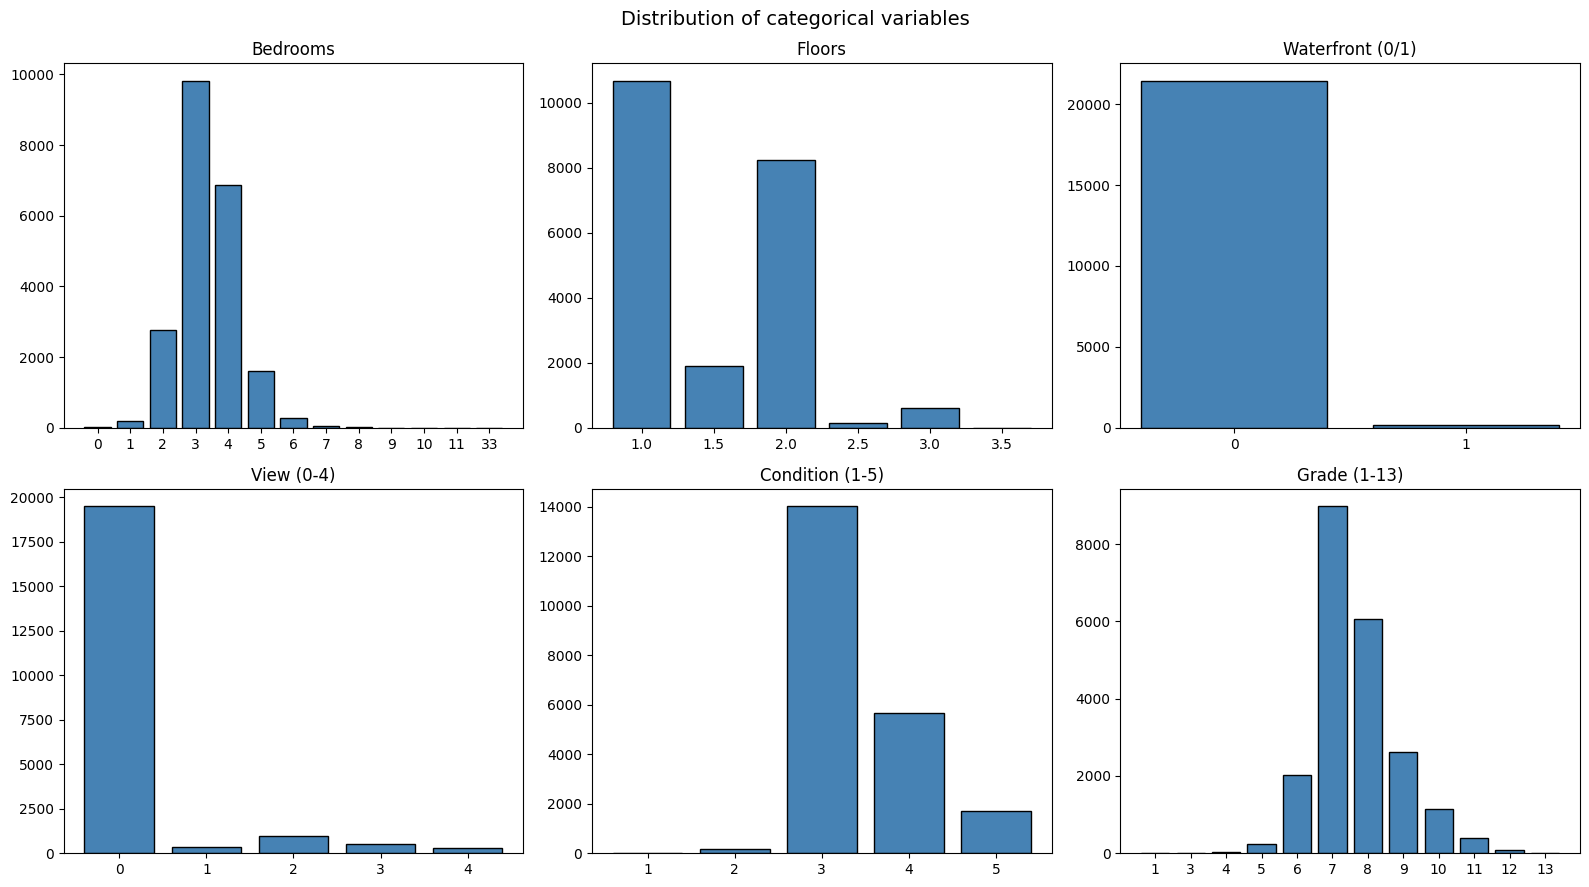

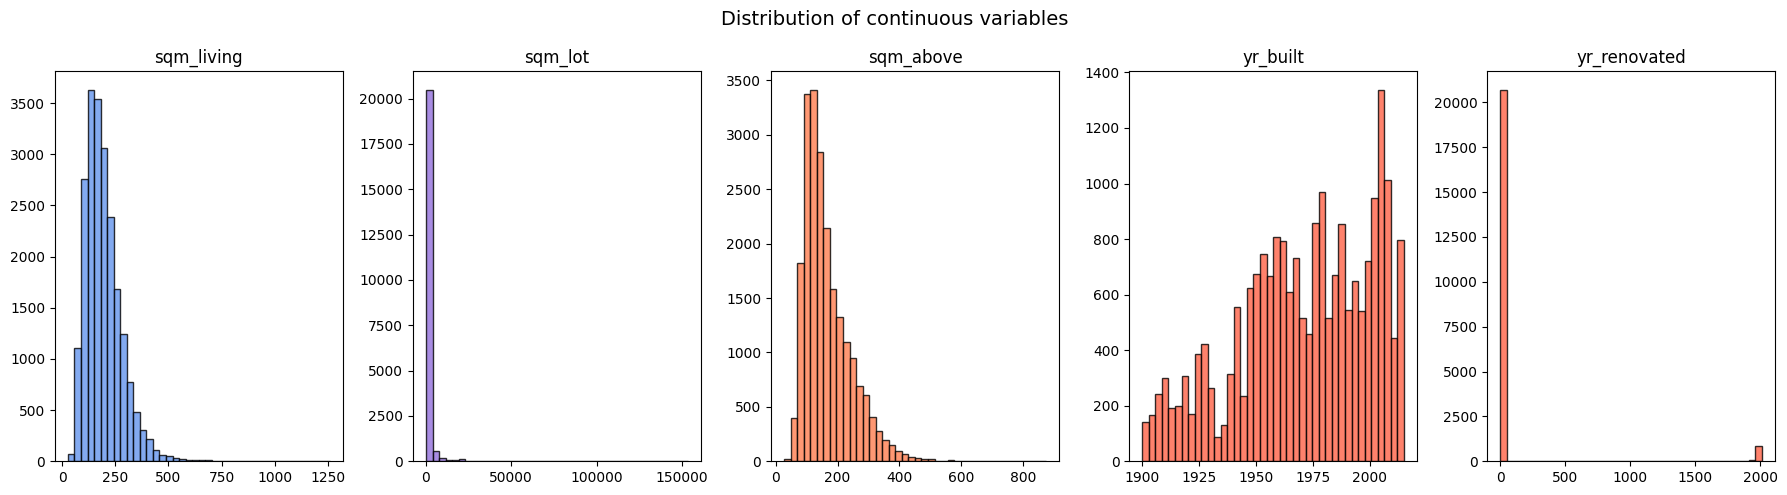

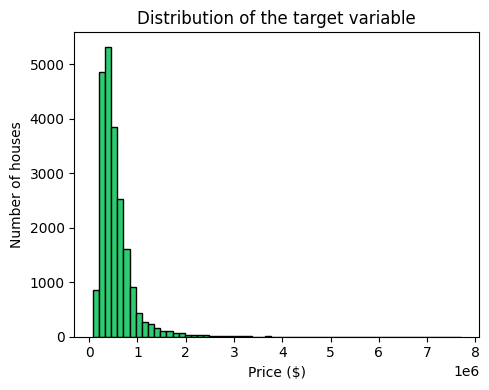

Price statistics : {'count': 21610.0, 'mean': 540085.0, 'std': 367153.0, 'min': 75000.0, '25%': 321612.0, '50%': 450000.0, '75%': 645000.0, 'max': 7700000.0}


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution of categorical variables", fontsize=14)

categoricals = ['bedrooms', 'floors', 'waterfront', 'view', 'condition', 'grade']
titles = ['Bedrooms', 'Floors', 'Waterfront (0/1)', 'View (0-4)', 'Condition (1-5)', 'Grade (1-13)']

for ax, col, title in zip(axes.flatten(), categoricals, titles):
    counts = df[col].value_counts().sort_index()
    ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([str(i) for i in counts.index], rotation=0)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Distribution of continuous variables", fontsize=14)
for ax, col, color in zip(axes,
                           ['sqm_living', 'sqm_lot', 'sqm_above', 'yr_built', 'yr_renovated'],
                           ['cornflowerblue', 'mediumpurple', 'coral', 'tomato', 'tomato']):
    ax.hist(df[col], bins=40, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(col)
plt.tight_layout()
plt.show()



plt.figure(figsize=(5, 4))
plt.hist(df['price'], bins=60, color='#2ecc71', edgecolor='black')
plt.title("Distribution of the target variable")
plt.xlabel("Price ($)")
plt.ylabel("Number of houses")
plt.tight_layout()
plt.show()
print(f"Price statistics : {df['price'].describe().round(0).to_dict()}")

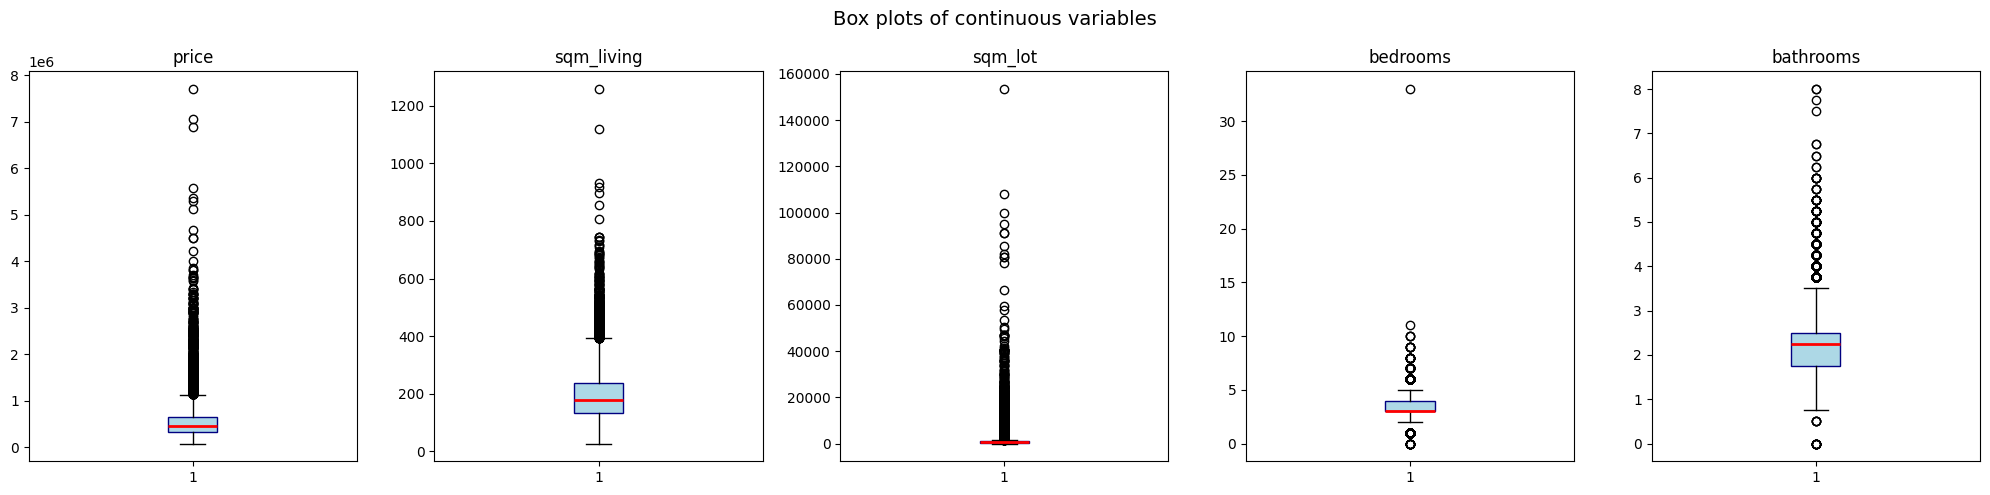

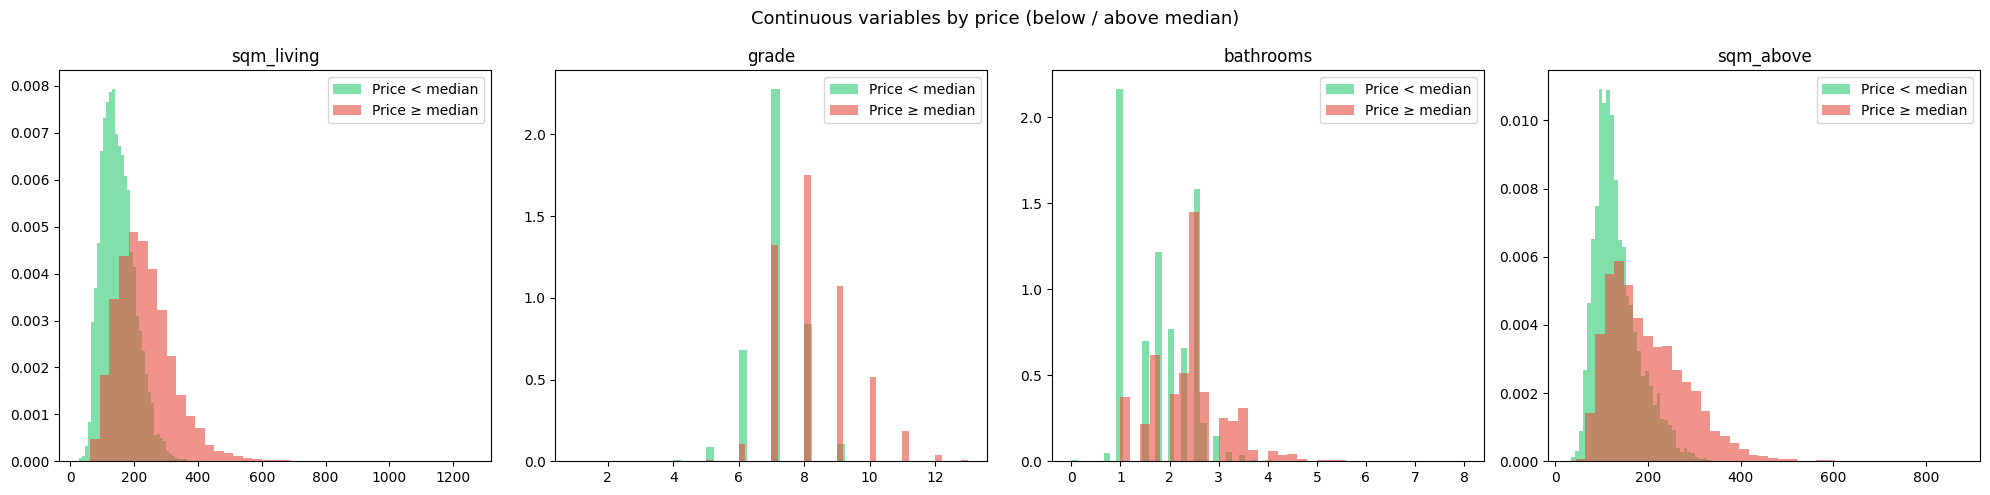

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Box plots of continuous variables", fontsize=14)
for ax, col in zip(axes, ['price', 'sqm_living', 'sqm_lot', 'bedrooms', 'bathrooms']):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Continuous variables by price (below / above median)",
             fontsize=13)
for ax, col in zip(axes, ['sqm_living', 'grade', 'bathrooms', 'sqm_above']):
    for val, label, color in [(False, 'Price < median', '#2ecc71'), (True, 'Price ≥ median', '#e74c3c')]:
        ax.hist(df[(df['price'] >= df['price'].median()) == val][col], bins=40,
                alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [23]:
price = df['price']

Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1
iqr_mask = (price < Q1 - 1.5 * IQR) | (price > Q3 + 1.5 * IQR)
print(f"Outliers IQR : {iqr_mask.sum()}")

median = price.median()
mad = (price - median).abs().median()
modified_z = 0.6745 * (price - median) / mad
mad_mask = abs(modified_z) > 3.5
print(f"Outliers modified Z-score : {mad_mask.sum()}")

low = price.quantile(0.01)
high = price.quantile(0.99)
pct_mask = (price < low) | (price > high)
print(f"Outliers percentiles : {pct_mask.sum()}")

outliers_combined = df[iqr_mask & mad_mask & pct_mask]
print(f"Outliers in the 3 methods : {len(outliers_combined)}")
outliers_combined[['price','sqm_living','grade','bedrooms']].describe()

Outliers IQR : 1140
Outliers modified Z-score : 928
Outliers percentiles : 434
Outliers in the 3 methods : 217


,price,sqm_living,grade,bedrooms
count,2.170000e+02,217.000000,217.000000,217.000000
mean,2.706587e+06,462.613699,10.677419,4.350230
std,8.368498e+05,143.016575,1.141432,1.016946
min,1.965000e+06,242.476830,7.000000,2.000000
25%,2.205000e+06,375.328120,10.000000,4.000000
50%,2.453500e+06,427.353800,11.000000,4.000000
75%,2.950000e+06,509.108440,11.000000,5.000000
max,7.700000e+06,1257.906620,13.000000,8.000000


### Saving in clean folder

In [24]:
os.makedirs("data/clean", exist_ok=True)

df.to_csv("data/clean/kc_house_data_clean.csv", index=False)

print("\nSaved in clean folder.")


Saved in clean folder.
